# Exploratory Data Analysis (EDA) - Twitter Dataset

**Dataset Columns:** id, text, created_at, username, likes, retweets, topic

**Purpose:** Analyze scraped Twitter data to understand patterns, quality, and prepare for clustering

---

## 1. Setup and Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn plotly wordcloud langdetect

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 8.5 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.3 MB 8.7 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 8.3 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.9 MB/s  0:00:01
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.9 MB 6.1 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 6.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 6.5 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 6.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 6.7 MB/s eta 0:00:01
   --------------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from collections import Counter
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Data

In [3]:
# Load your CSV file
# CHANGE THIS PATH to your actual CSV file location
df = pd.read_csv('trendingtopic.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\n First few rows:")
df.head(10)

Dataset Shape: (10595, 8)
Columns: ['id', 'text', 'created_at', 'username', 'likes', 'retweets', 'topic', 'timestamp']

 First few rows:


,id,text,created_at,username,likes,retweets,topic,timestamp
0,1960875468531621946,@PsyGuy007 bien vue super les gars...,2025-08-28,JaegerStep78492,0.0,NaN,Super Bowl LX,NaN
1,1960973143008292871,"You know what, I've ALSO been a splendid nigga...",2025-08-28,JSRingo,209.0,NaN,Super Bowl LX,NaN
2,1961159089544990909,@fashion_nfl Don’t think enough people are tal...,2025-08-28,p23rce,479.0,NaN,Super Bowl LX,NaN
3,1960932935676387741,RT @tahsin_adib: NINGNING telling winter it mu...,2025-08-28,hidden_faayz,0.0,NaN,Winter Olympics 2026 Milano,NaN
4,1961193691605078397,🤚🤚🤚💙2026!!!,2025-08-28,defloody,1.0,NaN,Winter Olympics 2026 Milano,NaN
5,1961003661548741029,Super sleepy. https://t.co/FMEc5ShIuv,2025-08-28,FajitaFantom,17.0,NaN,Super Bowl LX,NaN
6,1961078342188240986,@FabrizioRomano Check $RIZZ out guysWe're stil...,2025-08-28,Nazariite,3.0,NaN,Super Bowl LX,NaN
7,1960861972188033264,Nvidia (NVDA) earnings report Q2 2026 https://...,2025-08-28,KWoljevach71778,54.0,NaN,Winter Olympics 2026 Milano,NaN
8,1961104466297659629,“Republicans against Trump”Supports democrat w...,2025-08-28,mesnickerlicker,28.0,NaN,Super Bowl LX,NaN
9,1961169372170309929,RT @laymagdalene333: not super surprising but ...,2025-08-28,rosyghoul,0.0,NaN,Super Bowl LX,NaN


## 3. Basic Data Quality Checks

In [6]:
# Check data types
print("Data Types:")
print(df.dtypes)
print("\n" + "="*50 + "\n")

# Check for missing values
print("❌ Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df)
print("\n" + "="*50 + "\n")

# Check for duplicates
duplicates_id = df.duplicated(subset='id').sum()
duplicates_text = df.duplicated(subset='text').sum()
print(f"Duplicate IDs: {duplicates_id}")
print(f"Duplicate Texts: {duplicates_text} ({duplicates_text/len(df)*100:.2f}%)")
print("\n" + "="*50 + "\n")

Data Types:
id                str
text              str
created_at        str
username          str
likes         float64
retweets      float64
topic             str
timestamp     float64
dtype: object


❌ Missing Values:
            Missing Count  Percentage
id                      0    0.000000
text                    0    0.000000
created_at              0    0.000000
username               16    0.151015
likes                   0    0.000000
retweets            10595  100.000000
topic                   0    0.000000
timestamp           10595  100.000000


Duplicate IDs: 1
Duplicate Texts: 277 (2.61%)




In [8]:
# Check for empty or very short tweets
df['text_length'] = df['text'].astype(str).str.len()

print(f"📏 Text Length Statistics:")
print(f"  • Mean: {df['text_length'].mean():.1f} characters")
print(f"  • Median: {df['text_length'].median():.1f} characters")
print(f"  • Min: {df['text_length'].min()} characters")
print(f"  • Max: {df['text_length'].max()} characters")
print(f"\n⚠️  Tweets with <10 characters: {(df['text_length'] < 10).sum()}")
print(f"⚠️  Empty tweets: {(df['text'].astype(str).str.strip() == '').sum()}")

# Check for retweets (tweets starting with RT)
df['is_retweet'] = df['text'].astype(str).str.startswith('RT @')
print(f"\nRetweets (starting with 'RT @'): {df['is_retweet'].sum()} ({df['is_retweet'].sum()/len(df)*100:.1f}%)")

📏 Text Length Statistics:
  • Mean: 132.1 characters
  • Median: 121.0 characters
  • Min: 4 characters
  • Max: 2041 characters

⚠️  Tweets with <10 characters: 10
⚠️  Empty tweets: 0

Retweets (starting with 'RT @'): 2302 (21.7%)


## 4. Text Length Distribution

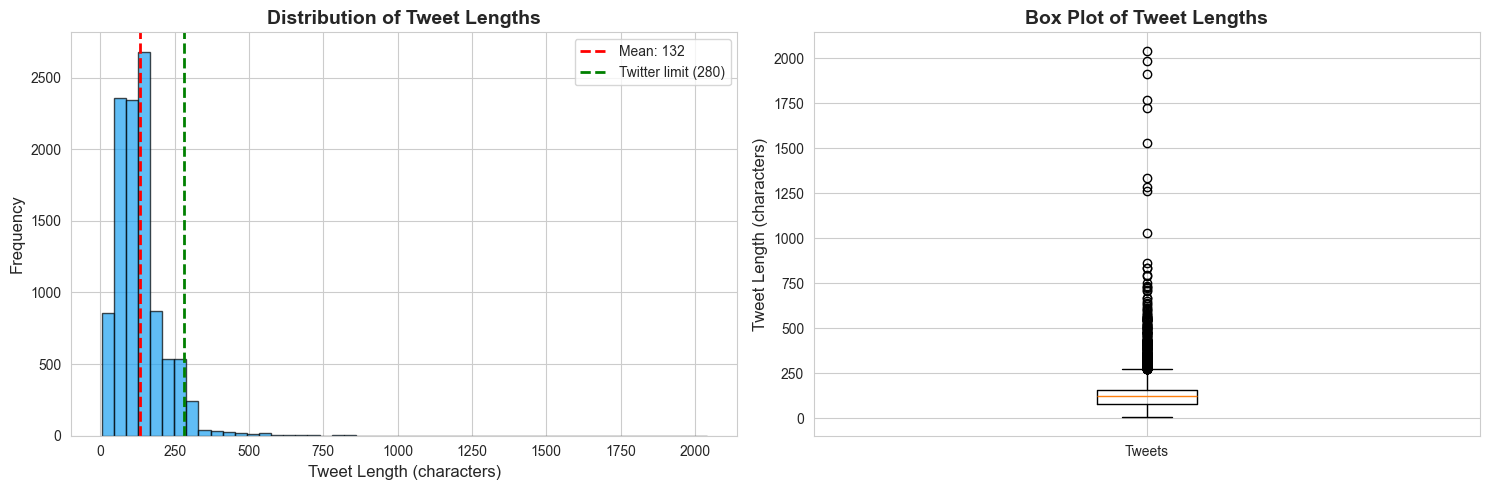


tweets at or near character limit (>270 chars): 669


In [ ]:
# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['text_length'], bins=50, color='#1DA1F2', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Tweet Length (characters)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Tweet Lengths', fontsize=14, fontweight='bold')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["text_length"].mean():.0f}')
axes[0].axvline(280, color='green', linestyle='--', linewidth=2, label='Twitter limit (280)')
axes[0].legend()

# Box plot
axes[1].boxplot(df['text_length'], vert=True)
axes[1].set_ylabel('Tweet Length (characters)', fontsize=12)
axes[1].set_title('Box Plot of Tweet Lengths', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Tweets'])

plt.tight_layout()
plt.show()

print(f"\ntweets at or near character limit (>270 chars): {(df['text_length'] > 270).sum()}")

## 5. Topic Distribution

In [13]:
# Topic distribution
topic_counts = df['topic'].value_counts()

print(f"\nNumber of unique topics: {df['topic'].nunique()}")
print("Topic Distribution:")
print(topic_counts)




Number of unique topics: 3
Topic Distribution:
topic
Super Bowl LX                  4999
Winter Olympics 2026 Milano    4999
Bangladesh Election 2026        597
Name: count, dtype: int64


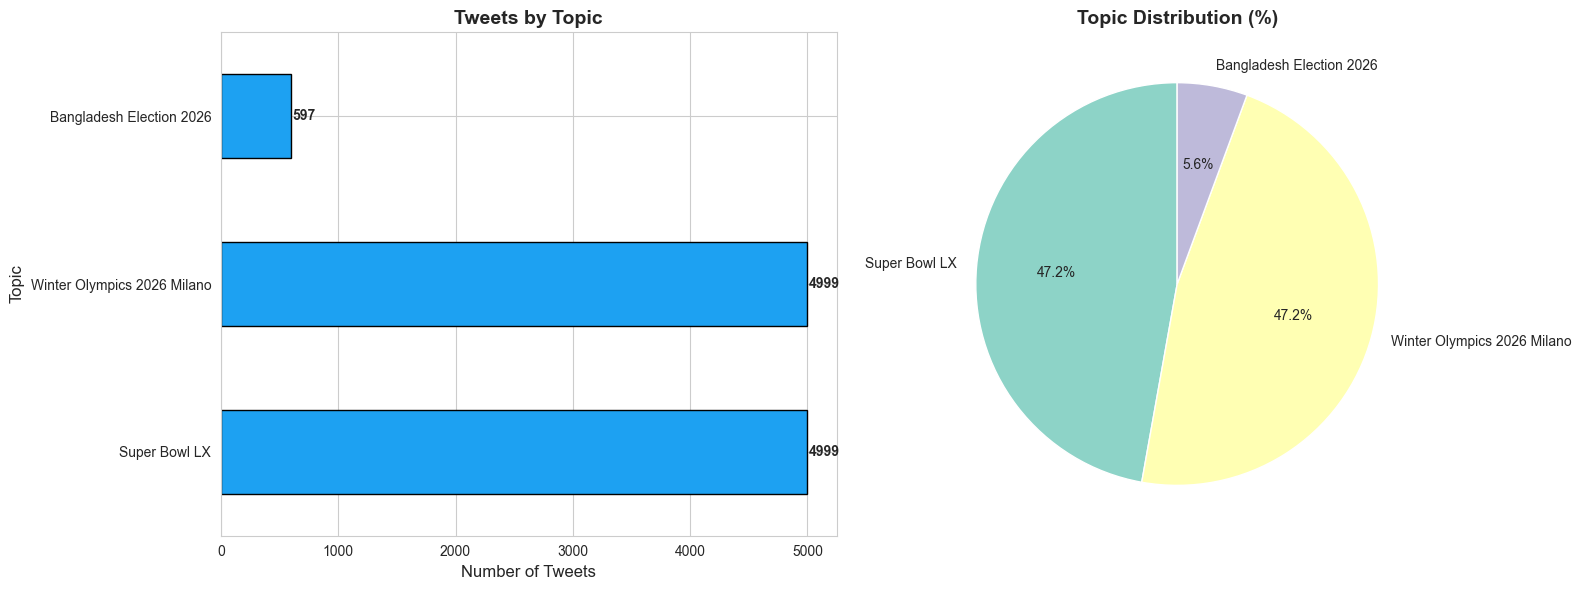

In [14]:
# Visualize topic distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
topic_counts.plot(kind='barh', ax=axes[0], color='#1DA1F2', edgecolor='black')
axes[0].set_xlabel('Number of Tweets', fontsize=12)
axes[0].set_ylabel('Topic', fontsize=12)
axes[0].set_title('Tweets by Topic', fontsize=14, fontweight='bold')

# Add value labels
for i, v in enumerate(topic_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontweight='bold')

# Pie chart
colors = plt.cm.Set3(range(len(topic_counts)))
axes[1].pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Topic Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Engagement Analysis (Likes)

In [16]:
# Engagement statistics
print("❤️  LIKES Statistics:")
print(f"  • Total likes: {df['likes'].sum():,}")
print(f"  • Mean likes per tweet: {df['likes'].mean():.2f}")
print(f"  • Median likes: {df['likes'].median():.0f}")
print(f"  • Max likes: {df['likes'].max():,}")
print(f"  • Tweets with 0 likes: {(df['likes'] == 0).sum()} ({(df['likes'] == 0).sum()/len(df)*100:.1f}%)")

❤️  LIKES Statistics:
  • Total likes: 214,309,542.0
  • Mean likes per tweet: 20227.42
  • Median likes: 40
  • Max likes: 12,051,192.0
  • Tweets with 0 likes: 2336 (22.0%)


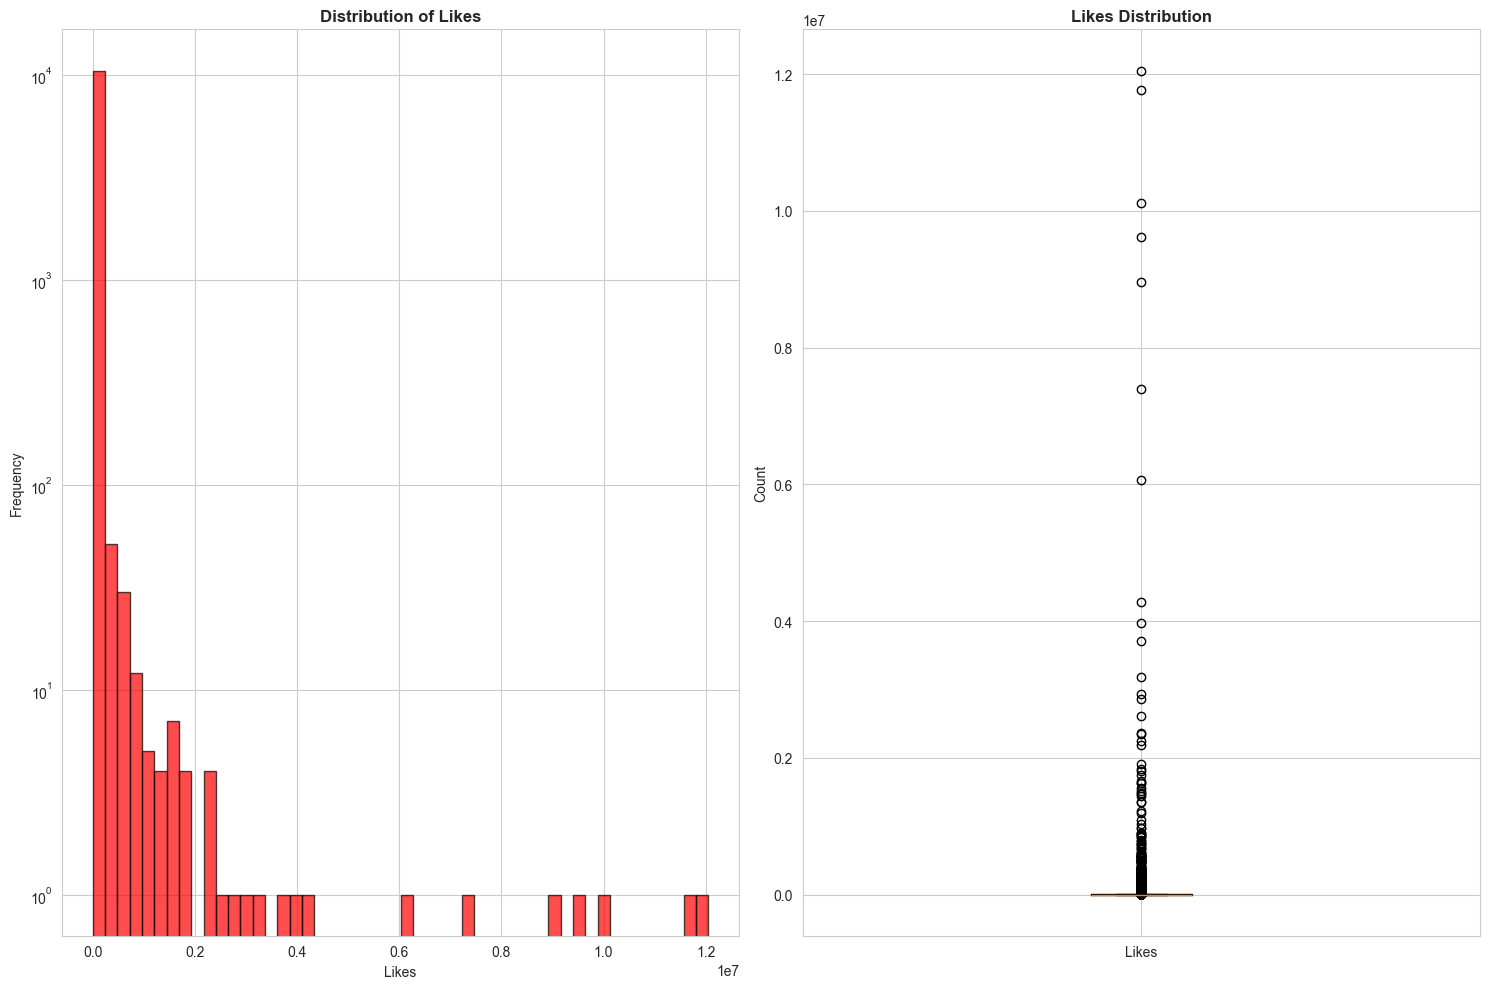

In [19]:
# Engagement distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# Likes histogram
axes[0].hist(df['likes'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Likes')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Likes', fontweight='bold')
axes[0].set_yscale('log')  # Log scale for better visibility

# Box plot
axes[1].boxplot([df['likes']], labels=['Likes'], vert=True)
axes[1].set_ylabel('Count')
axes[1].set_title('Likes Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Engagement by Topic

Engagement by Topic:
                             Avg Likes  Total Likes  Tweet Count  Avg Retweets
topic                                                                         
Super Bowl LX                 25991.04  129929201.0         4999           NaN
Winter Olympics 2026 Milano   16641.32   83189941.0         4999           NaN
Bangladesh Election 2026       1993.97    1190400.0          597           NaN


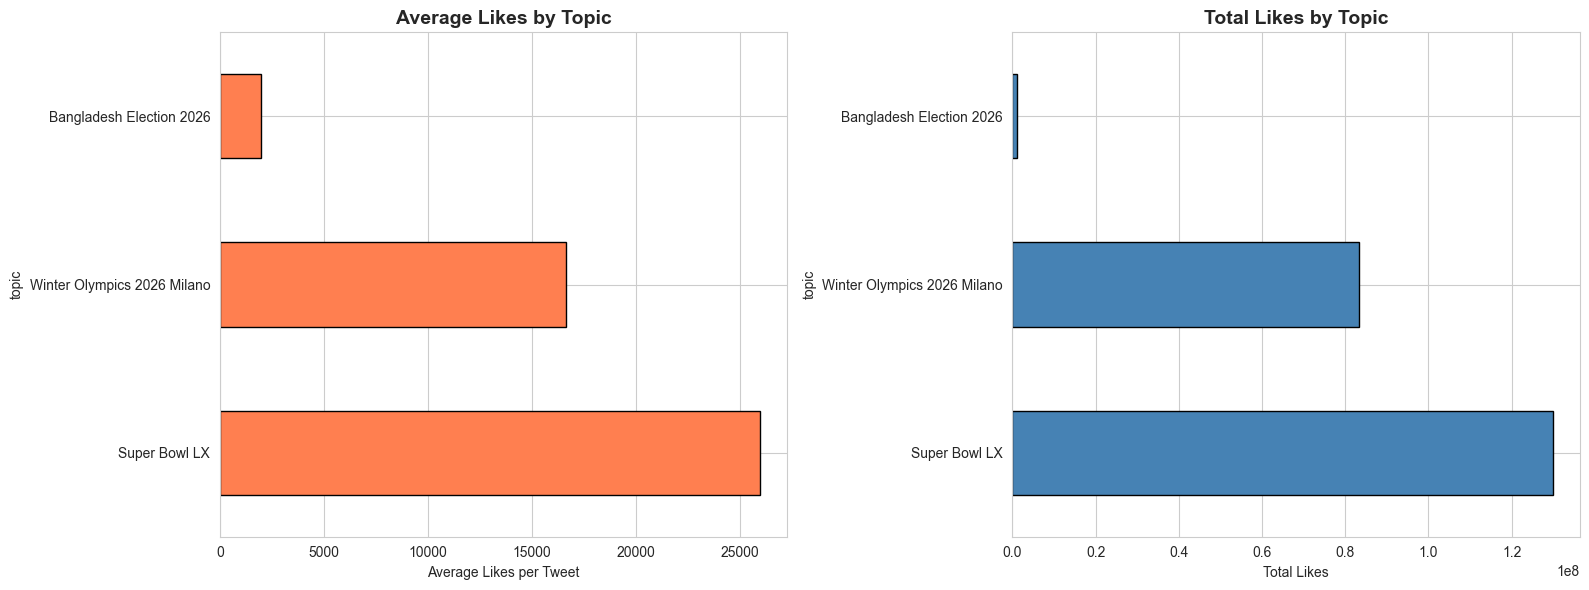

In [22]:
# Average engagement by topic
topic_engagement = df.groupby('topic').agg({
    'likes': ['mean', 'sum', 'count'],
    'retweets': 'mean'
}).round(2)

topic_engagement.columns = ['Avg Likes', 'Total Likes', 'Tweet Count', 'Avg Retweets']
topic_engagement = topic_engagement.sort_values('Total Likes', ascending=False)

print("Engagement by Topic:")
print(topic_engagement)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average likes by topic
topic_engagement['Avg Likes'].plot(kind='barh', ax=axes[0], color='coral', edgecolor='black')
axes[0].set_xlabel('Average Likes per Tweet')
axes[0].set_title('Average Likes by Topic', fontsize=14, fontweight='bold')

# Total likes by topic
topic_engagement['Total Likes'].plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Total Likes')
axes[1].set_title('Total Likes by Topic', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Temporal Analysis

In [23]:
# Convert created_at to datetime
df['datetime'] = pd.to_datetime(df['created_at'], errors='coerce')
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()

print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of days covered: {(df['date'].max() - df['date'].min()).days + 1}")
print(f"Average tweets per day: {len(df) / ((df['date'].max() - df['date'].min()).days + 1):.1f}")

Date Range: 2025-08-28 to 2026-03-01
Number of days covered: 186
Average tweets per day: 57.0


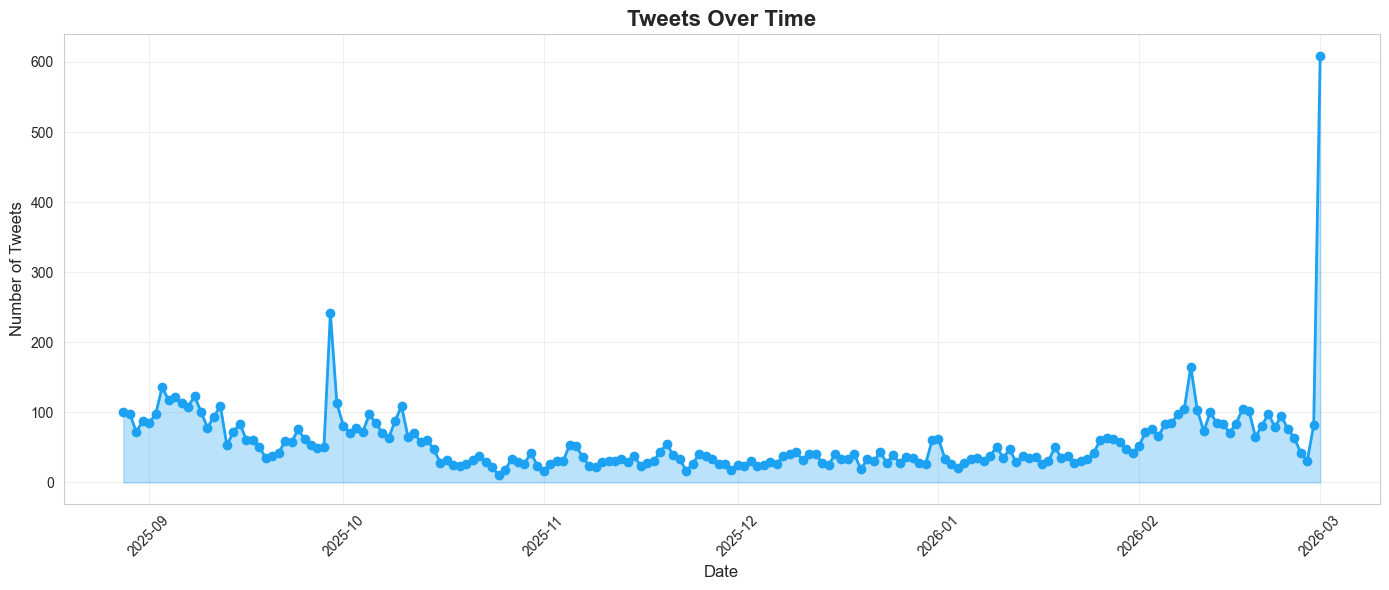


Peak day: 2026-03-01 (609 tweets)
Slowest day: 2025-10-25 (10 tweets)


In [24]:
# Tweets over time
tweets_per_day = df.groupby('date').size()

plt.figure(figsize=(14, 6))
plt.plot(tweets_per_day.index, tweets_per_day.values, marker='o', linewidth=2, markersize=6, color='#1DA1F2')
plt.fill_between(tweets_per_day.index, tweets_per_day.values, alpha=0.3, color='#1DA1F2')
plt.title('Tweets Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPeak day: {tweets_per_day.idxmax()} ({tweets_per_day.max()} tweets)")
print(f"Slowest day: {tweets_per_day.idxmin()} ({tweets_per_day.min()} tweets)")

## 9. Language Detection

In [ ]:
from langdetect import detect, LangDetectException

def detect_language(text):
    try:
        if len(str(text).strip()) < 10:
            return 'unknown'
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

sample_size = min(10000, len(df))
df_sample = df.sample(sample_size, random_state=42)
df_sample['language'] = df_sample['text'].apply(detect_language)

lang_counts = df_sample['language'].value_counts()

print(f"Language Distribution (sample of {sample_size} tweets):\n")
for lang, count in lang_counts.head(10).items():
    pct = count / len(df_sample) * 100
    print(f"  {lang}: {count} ({pct:.1f}%)")

print(f"\nEnglish tweets: {(df_sample['language'] == 'en').sum()} ({(df_sample['language'] == 'en').sum()/len(df_sample)*100:.1f}%)")

Language Distribution (sample of 10000 tweets):

  en: 8082 (80.8%)
  es: 337 (3.4%)
  pt: 220 (2.2%)
  fr: 195 (1.9%)
  de: 144 (1.4%)
  he: 138 (1.4%)
  id: 137 (1.4%)
  it: 121 (1.2%)
  th: 60 (0.6%)
  ja: 55 (0.5%)

English tweets: 8082 (80.8%)


## 10. Word Cloud & Common Words

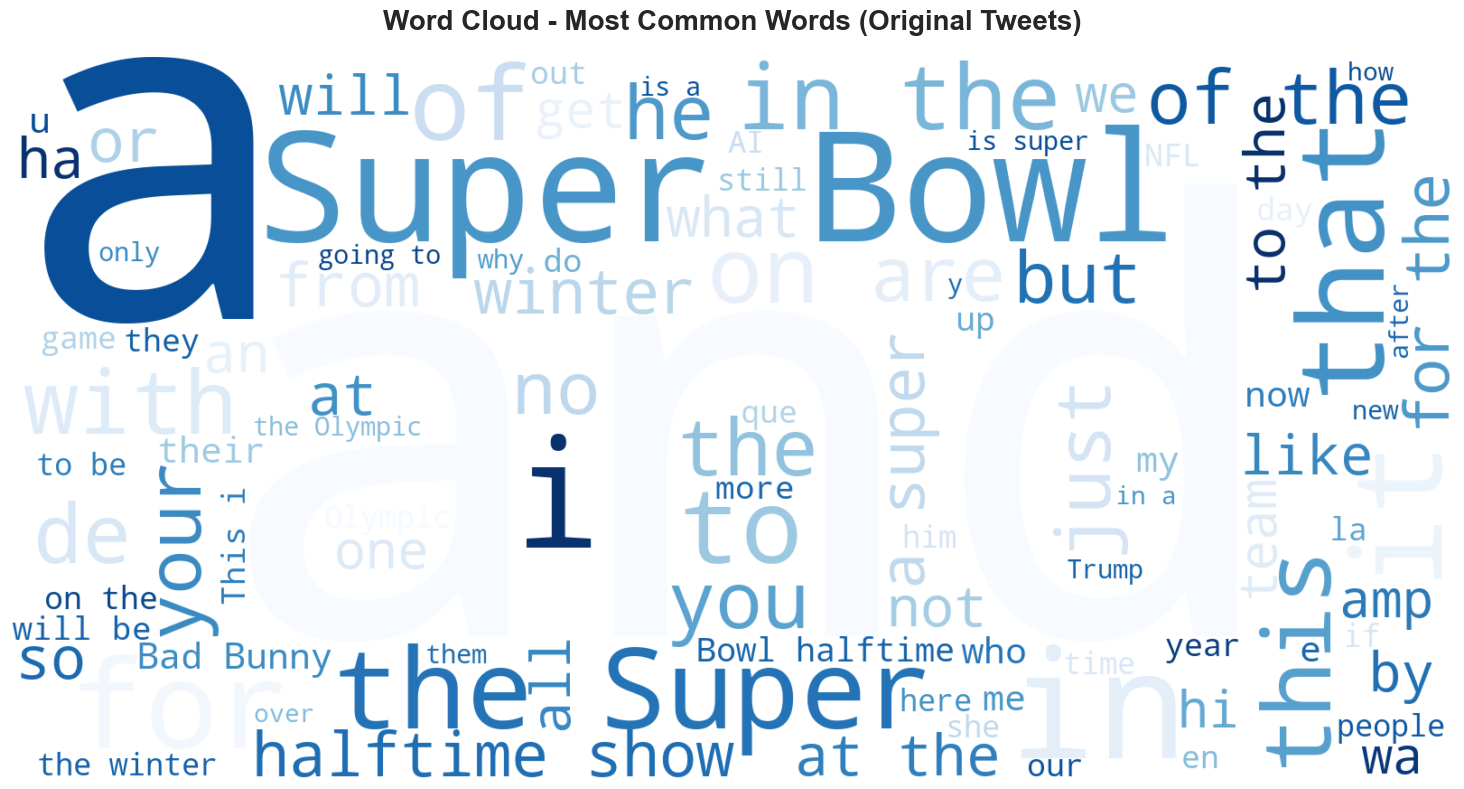

In [30]:
# Combine all text (excluding retweets for cleaner wordcloud)
original_tweets = df[~df['is_retweet']]
all_text = ' '.join(original_tweets['text'].astype(str).values)

# Create word cloud
wordcloud = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    colormap='Blues',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    stopwords={'https', 'http', 'RT', 't', 'co', 's'}  # Common Twitter noise
).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Common Words (Original Tweets)', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

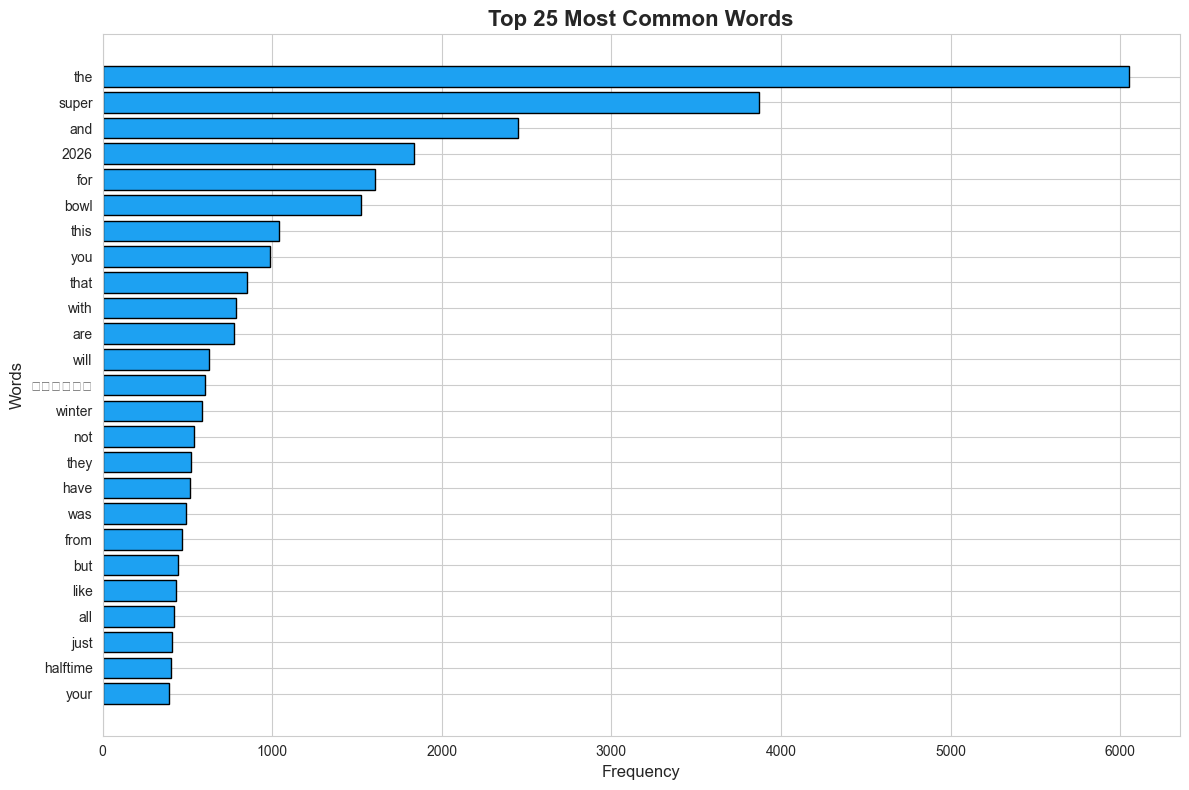

In [31]:
# Extract all words (from original tweets)
all_words = ' '.join(original_tweets['text'].astype(str).values).lower().split()

# Remove URLs, mentions, and common noise
all_words = [word for word in all_words if not word.startswith(('http', '@', 'www', 'rt'))]
all_words = [word for word in all_words if len(word) > 2]  # Remove very short words

# Most common words
word_freq = Counter(all_words)
top_words = word_freq.most_common(25)

words, counts = zip(*top_words)

plt.figure(figsize=(12, 8))
plt.barh(words, counts, color='#1DA1F2', edgecolor='black')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.title('Top 25 Most Common Words', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Hashtag & Mention Analysis

In [35]:
# Extract hashtags
all_hashtags = []
for text in df['text'].astype(str):
    hashtags = re.findall(r'#\w+', text.lower())
    all_hashtags.extend(hashtags)

# Extract mentions
all_mentions = []
for text in df['text'].astype(str):
    mentions = re.findall(r'@\w+', text.lower())
    all_mentions.extend(mentions)

print(f"HASHTAG Analysis:")
print(f"  • Total hashtags: {len(all_hashtags)}")
print(f"  • Unique hashtags: {len(set(all_hashtags))}")
print(f"  • Tweets with hashtags: {df['text'].astype(str).str.contains('#').sum()} ({df['text'].astype(str).str.contains('#').sum()/len(df)*100:.1f}%)")

print(f"\nMENTION Analysis:")
print(f"  • Total mentions: {len(all_mentions)}")
print(f"  • Unique users mentioned: {len(set(all_mentions))}")
print(f"  • Tweets with mentions: {df['text'].astype(str).str.contains('@').sum()} ({df['text'].astype(str).str.contains('@').sum()/len(df)*100:.1f}%)")

HASHTAG Analysis:
  • Total hashtags: 2798
  • Unique hashtags: 2162
  • Tweets with hashtags: 1124 (10.6%)

MENTION Analysis:
  • Total mentions: 8908
  • Unique users mentioned: 6586
  • Tweets with mentions: 6687 (63.1%)


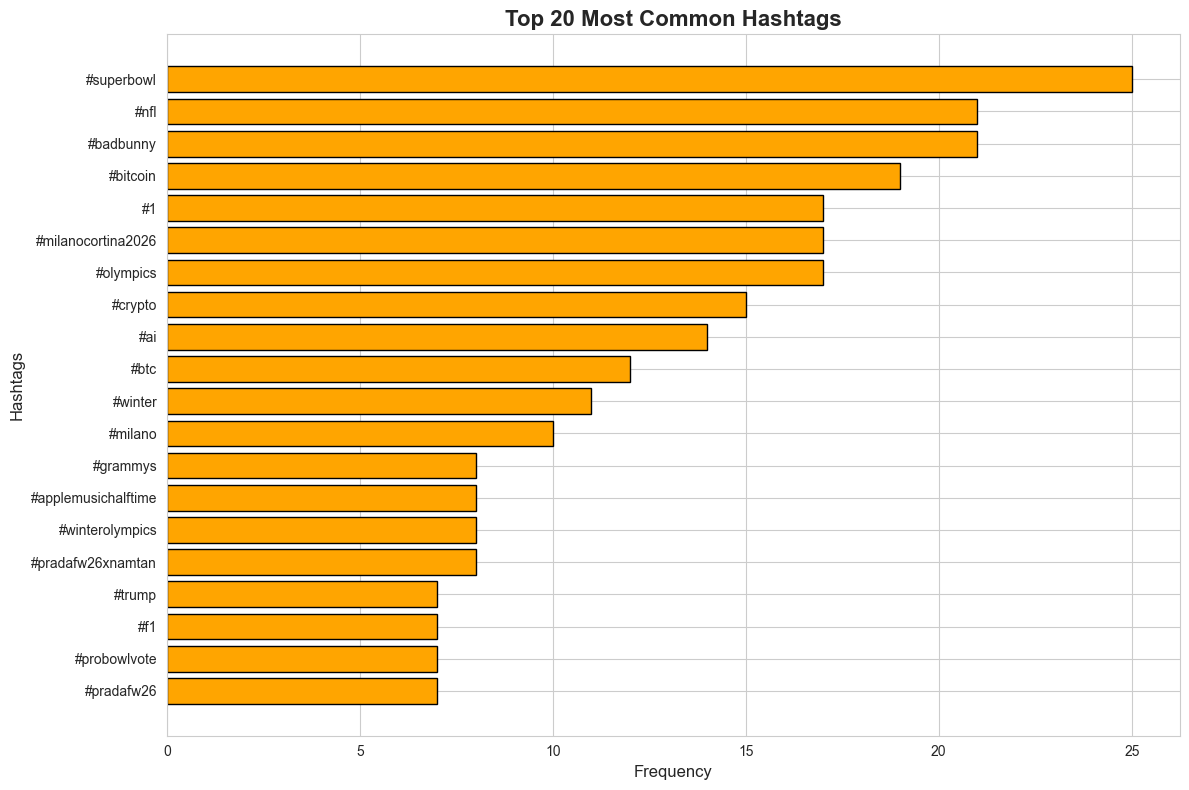

In [36]:
# Top hashtags
if len(all_hashtags) > 0:
    hashtag_freq = Counter(all_hashtags)
    top_hashtags = hashtag_freq.most_common(20)
    
    tags, tag_counts = zip(*top_hashtags)
    
    plt.figure(figsize=(12, 8))
    plt.barh(tags, tag_counts, color='orange', edgecolor='black')
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Hashtags', fontsize=12)
    plt.title('Top 20 Most Common Hashtags', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No hashtags found")

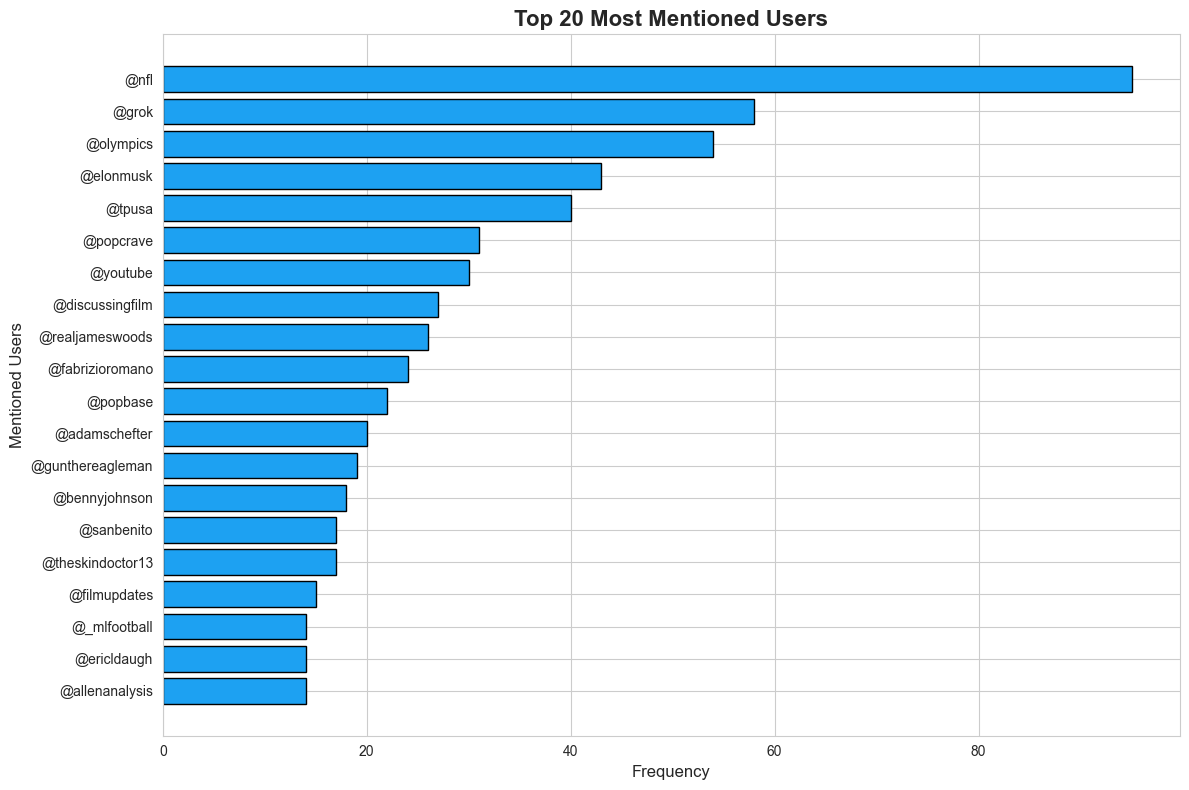

In [37]:
# Top mentioned users
if len(all_mentions) > 0:
    mention_freq = Counter(all_mentions)
    top_mentions = mention_freq.most_common(20)
    
    users, user_counts = zip(*top_mentions)
    
    plt.figure(figsize=(12, 8))
    plt.barh(users, user_counts, color='#1DA1F2', edgecolor='black')
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Mentioned Users', fontsize=12)
    plt.title('Top 20 Most Mentioned Users', fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("No mentions found")

## 12. Special Characters & Emoji Analysis

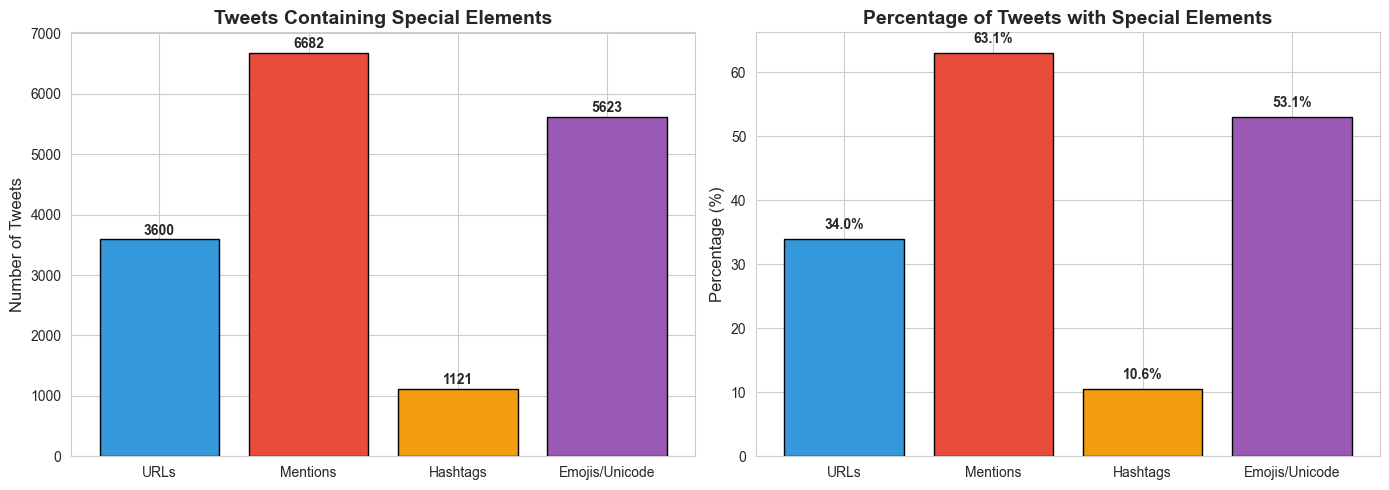


Tweets with URLs: 3600 (34.0%)
Tweets with mentions: 6682 (63.1%)
Tweets with hashtags: 1121 (10.6%)
Tweets with emojis/unicode: 5623 (53.1%)


In [39]:
# Count tweets with URLs
df['has_url'] = df['text'].astype(str).str.contains(r'http|www', case=False, regex=True)
url_count = df['has_url'].sum()

# Count tweets with mentions
df['has_mention'] = df['text'].astype(str).str.contains(r'@\w+', case=False, regex=True)
mention_count = df['has_mention'].sum()

# Count tweets with hashtags
df['has_hashtag'] = df['text'].astype(str).str.contains(r'#\w+', case=False, regex=True)
hashtag_count = df['has_hashtag'].sum()

# Count tweets with emojis/special unicode
df['has_emoji'] = df['text'].astype(str).str.contains(r'[^\x00-\x7F]+', regex=True)
emoji_count = df['has_emoji'].sum()

# Visualization
categories = ['URLs', 'Mentions', 'Hashtags', 'Emojis/Unicode']
counts = [url_count, mention_count, hashtag_count, emoji_count]
percentages = [c/len(df)*100 for c in counts]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(categories, counts, color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black')
axes[0].set_ylabel('Number of Tweets', fontsize=12)
axes[0].set_title('Tweets Containing Special Elements', fontsize=14, fontweight='bold')
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

# Percentage chart
axes[1].bar(categories, percentages, color=['#3498db', '#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black')
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_title('Percentage of Tweets with Special Elements', fontsize=14, fontweight='bold')
for i, v in enumerate(percentages):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTweets with URLs: {url_count} ({url_count/len(df)*100:.1f}%)")
print(f"Tweets with mentions: {mention_count} ({mention_count/len(df)*100:.1f}%)")
print(f"Tweets with hashtags: {hashtag_count} ({hashtag_count/len(df)*100:.1f}%)")
print(f"Tweets with emojis/unicode: {emoji_count} ({emoji_count/len(df)*100:.1f}%)")

## 13. Data Quality Summary Report

In [42]:
print("="*80)
print("DATA QUALITY SUMMARY REPORT")
print("="*80)

print(f"\nDATASET SIZE:")
print(f"  • Total tweets: {len(df):,}")
print(f"  • Columns: {len(df.columns)}")
print(f"  • Date range: {df['date'].min()} to {df['date'].max()}")

print(f"\nTOPICS:")
print(f"  • Number of topics: {df['topic'].nunique()}")
for topic, count in df['topic'].value_counts().items():
    print(f"    - {topic}: {count:,} tweets ({count/len(df)*100:.1f}%)")

print(f"\nDATA QUALITY:")
print(f"  • Duplicate tweet IDs: {duplicates_id}")
print(f"  • Duplicate texts: {duplicates_text} ({duplicates_text/len(df)*100:.2f}%)")
print(f"  • Missing text: {df['text'].isnull().sum()}")
print(f"  • Very short tweets (<10 chars): {(df['text_length'] < 10).sum()}")
print(f"  • Empty tweets: {(df['text'].astype(str).str.strip() == '').sum()}")
print(f"  • Retweets (RT @...): {df['is_retweet'].sum()} ({df['is_retweet'].sum()/len(df)*100:.1f}%)")

print(f"\nTEXT STATISTICS:")
print(f"  • Mean length: {df['text_length'].mean():.1f} characters")
print(f"  • Median length: {df['text_length'].median():.1f} characters")
print(f"  • Shortest tweet: {df['text_length'].min()} characters")
print(f"  • Longest tweet: {df['text_length'].max()} characters")

print(f"\nENGAGEMENT:")
print(f"  • Total likes: {df['likes'].sum():,}")
print(f"  • Average likes: {df['likes'].mean():.2f}")

print(f"\nCONTENT FEATURES:")
print(f"  • Tweets with URLs: {df['has_url'].sum():,} ({df['has_url'].sum()/len(df)*100:.1f}%)")
print(f"  • Tweets with mentions: {df['has_mention'].sum():,} ({df['has_mention'].sum()/len(df)*100:.1f}%)")
print(f"  • Tweets with hashtags: {df['has_hashtag'].sum():,} ({df['has_hashtag'].sum()/len(df)*100:.1f}%)")
print(f"  • Tweets with emojis: {df['has_emoji'].sum():,} ({df['has_emoji'].sum()/len(df)*100:.1f}%)")

print("\n" + "="*80)

DATA QUALITY SUMMARY REPORT

DATASET SIZE:
  • Total tweets: 10,595
  • Columns: 18
  • Date range: 2025-08-28 to 2026-03-01

TOPICS:
  • Number of topics: 3
    - Super Bowl LX: 4,999 tweets (47.2%)
    - Winter Olympics 2026 Milano: 4,999 tweets (47.2%)
    - Bangladesh Election 2026: 597 tweets (5.6%)

DATA QUALITY:
  • Duplicate tweet IDs: 1
  • Duplicate texts: 277 (2.61%)
  • Missing text: 0
  • Very short tweets (<10 chars): 10
  • Empty tweets: 0
  • Retweets (RT @...): 2302 (21.7%)

TEXT STATISTICS:
  • Mean length: 132.1 characters
  • Median length: 121.0 characters
  • Shortest tweet: 4 characters
  • Longest tweet: 2041 characters

ENGAGEMENT:
  • Total likes: 214,309,542.0
  • Average likes: 20227.42

CONTENT FEATURES:
  • Tweets with URLs: 3,600 (34.0%)
  • Tweets with mentions: 6,682 (63.1%)
  • Tweets with hashtags: 1,121 (10.6%)
  • Tweets with emojis: 5,623 (53.1%)



## 14. Save Cleaned Dataset (Optional)

In [44]:
# Create cleaned version
df_clean = df.copy()

print(f"Original dataset: {len(df_clean):,} tweets")

# Remove duplicates based on text
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset='text')
print(f"Removed {before - len(df_clean)} duplicate tweets")

# Remove retweets 
before = len(df_clean)
df_clean = df_clean[~df_clean['is_retweet']]
print(f"Removed {before - len(df_clean)} retweets")

# Remove very short tweets
before = len(df_clean)
df_clean = df_clean[df_clean['text_length'] >= 10]
print(f"Removed {before - len(df_clean)} very short tweets")

# Remove tweets with missing text
before = len(df_clean)
df_clean = df_clean[df_clean['text'].notna()]
print(f"Removed {before - len(df_clean)} tweets with missing text")

print(f"\nFinal cleaned dataset: {len(df_clean):,} tweets")
print(f"Total removed: {len(df) - len(df_clean):,} tweets ({(len(df) - len(df_clean))/len(df)*100:.1f}%)")

# Save cleaned dataset
df_clean.to_csv('trendingtopics_cleaned.csv', index=False)
print("\nCleaned dataset saved to 'trendingtopics_cleaned.csv'")

Original dataset: 10,595 tweets
Removed 277 duplicate tweets
Removed 2052 retweets
Removed 9 very short tweets
Removed 0 tweets with missing text

Final cleaned dataset: 8,257 tweets
Total removed: 2,338 tweets (22.1%)

Cleaned dataset saved to 'trendingtopics_cleaned.csv'
